
# Breast Cancer Dataset: Data Acquisition, Wrangling, and Exploratory Data Analysis

**Authors:** Bright Agbenu, Anandhi Kandaswamy, Sarah Sejoro

This notebook follows the following structure:
- **Part A:** Data Acquisition and Description
- **Part B:** Data Wrangling and Preprocessing
- **Part C:** Exploratory Data Analysis and Visualization

The analysis uses the **Breast Cancer Wisconsin (Diagnostic)** dataset from the **UCI Machine Learning Repository**. We attempt to transform the raw data into a clean, machine-learning-ready dataset and then use descriptive statistics and visualization to understand important patterns in the data.


In [1]:

# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

from IPython.display import display

# Global display and plotting settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("colorblind", 6)
diagnosis_palette = {"B": palette[0], "M": palette[1]}
diagnosis_order = ["B", "M"]

print("Libraries loaded successfully.")


Libraries loaded successfully.



## Part A. Data Acquisition and Description

### Dataset Source
- **Source:** UCI Machine Learning Repository
- **Dataset Name:** Breast Cancer Wisconsin (Diagnostic)
- **Official URL:** https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- **Access Date:** Recorded dynamically below when this notebook runs

For reproducibility, this notebook first looks for a local CSV copy of the dataset. If the local file is not available, it attempts to fetch the dataset from `ucimlrepo`.


In [2]:
ACCESS_DATE = date.today().isoformat()
DATASET_URL = "https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic"

dataset_source_used = None

try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "ucimlrepo", "-q"], check=False)
    from ucimlrepo import fetch_ucirepo

breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets
df_raw = pd.concat([X, y], axis=1)
dataset_source_used = "Direct fetch via ucimlrepo"

print(f"Dataset URL: {DATASET_URL}")
print(f"Access date: {ACCESS_DATE}")
print(f"Data loaded from: {dataset_source_used}")
print(f"Raw dataset shape: {df_raw.shape}")
display(df_raw.head())

Dataset URL: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
Access date: 2026-04-01
Data loaded from: Direct fetch via ucimlrepo
Raw dataset shape: (569, 31)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.9900,10.3800,122.8000,"1,001.0000",0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,"2,019.0000",0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,M
1,20.5700,17.7700,132.9000,"1,326.0000",0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,"1,956.0000",0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,M
2,19.6900,21.2500,130.0000,"1,203.0000",0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,"1,709.0000",0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,M
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,M
4,20.2900,14.3400,135.1000,"1,297.0000",0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,"1,575.0000",0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,M


In [3]:
rows, cols = df_raw.shape

dataset_description = pd.DataFrame({
    "Property": [
        "Number of records (rows)",
        "Number of columns in raw file",
        "Predictive features listed by UCI",
        "Target variable",
        "Identifier column",
        "Duplicate rows"
    ],
    "Value": [
        rows,
        cols,
        30,
        "diagnosis",
        "id",
        int(df_raw.duplicated().sum())
    ]
})

print("Dataset description summary:")
display(dataset_description)

print("\nColumn data types:")
dtype_table = (
    df_raw.dtypes
    .astype(str)
    .reset_index()
    .rename(columns={"index": "feature", 0: "dtype"})
)
display(dtype_table)

print("\nDescriptive statistics:")
display(df_raw.describe())

Dataset description summary:


,Property,Value
0,Number of records (rows),569
1,Number of columns in raw file,31
2,Predictive features listed by UCI,30
3,Target variable,diagnosis
4,Identifier column,id
5,Duplicate rows,0



Column data types:


,feature,dtype
0,radius1,float64
1,texture1,float64
2,perimeter1,float64
3,area1,float64
4,smoothness1,float64
5,compactness1,float64
6,concavity1,float64
7,concave_points1,float64
8,symmetry1,float64
9,fractal_dimension1,float64



Descriptive statistics:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.9690,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,0.4052,1.2169,2.8661,40.3371,0.0070,0.0255,0.0319,0.0118,0.0205,0.0038,16.2692,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839
std,3.5240,4.3010,24.2990,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,0.2773,0.5516,2.0219,45.4910,0.0030,0.0179,0.0302,0.0062,0.0083,0.0026,4.8332,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181
min,6.9810,9.7100,43.7900,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,0.1115,0.3602,0.7570,6.8020,0.0017,0.0023,0.0000,0.0000,0.0079,0.0009,7.9300,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550
25%,11.7000,16.1700,75.1700,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,0.2324,0.8339,1.6060,17.8500,0.0052,0.0131,0.0151,0.0076,0.0152,0.0022,13.0100,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715
50%,13.3700,18.8400,86.2400,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,0.3242,1.1080,2.2870,24.5300,0.0064,0.0204,0.0259,0.0109,0.0187,0.0032,14.9700,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800
75%,15.7800,21.8000,104.1000,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,0.4789,1.4740,3.3570,45.1900,0.0081,0.0324,0.0420,0.0147,0.0235,0.0046,18.7900,29.7200,125.4000,"1,084.0000",0.1460,0.3391,0.3829,0.1614,0.3179,0.0921
max,28.1100,39.2800,188.5000,"2,501.0000",0.1634,0.3454,0.4268,0.2012,0.3040,0.0974,2.8730,4.8850,21.9800,542.2000,0.0311,0.1354,0.3960,0.0528,0.0790,0.0298,36.0400,49.5400,251.2000,"4,254.0000",0.2226,1.0580,1.2520,0.2910,0.6638,0.2075


### Interpretation of Descriptive Statistics

The descriptive statistics table summarizes the main characteristics of the 569 observations across all 30 numerical features in the dataset. Overall, the variables show substantial variation in scale. For example, features such as `area1` and `area3` have much larger mean values and standard deviations than variables like `fractal_dimension1` and `fractal_dimension3`, which indicates that the dataset contains measurements recorded on very different numeric ranges.

A comparison of the mean and median suggests that several features are slightly right-skewed. This is especially noticeable in variables such as `area1`, `area2`, `area3`, `concavity3`, and `compactness3`, where the mean is higher than the median, suggesting the presence of larger values pulling the average upward. The wide gaps between minimum and maximum values also point to possible outliers in features like `radius3`, `perimeter3`, and `area3`.

The quartiles further show that some variables are more tightly clustered, while others are more spread out. For instance, `smoothness1` and `fractal_dimension1` appear relatively stable, whereas size-related features such as `radius`, `perimeter`, and `area` show much broader dispersion. These results provide an important first look at the data and suggest that scaling and outlier treatment will be useful during preprocessing.

In [4]:
# Create a data dictionary table

base_descriptions = {
    "radius": "distance from the center to points on the perimeter",
    "texture": "standard deviation of gray-scale values",
    "perimeter": "tumor perimeter measurement",
    "area": "tumor area measurement",
    "smoothness": "local variation in radius lengths",
    "compactness": "compactness measure computed as (perimeter^2 / area) - 1.0",
    "concavity": "severity of concave portions of the contour",
    "concave points": "number or extent of concave portions of the contour",
    "symmetry": "symmetry of the tumor shape",
    "fractal_dimension": "fractal dimension approximation of the contour"
}

suffix_descriptions = {
    "mean": "mean value of",
    "se": "standard error of",
    "worst": "worst or largest observed value of"
}

def describe_feature(col_name: str) -> str:
    if col_name == "id":
        return "Unique identifier for each patient sample."
    if col_name == "diagnosis":
        return "Target label indicating whether the tumor is benign (B) or malignant (M)."
    if col_name == "Unnamed: 32":
        return "Completely empty extra column present in the CSV file; not analytically useful."

    # Mapping numerical suffixes (1, 2, 3) to their descriptive counterparts
    num_to_desc_suffix = {
        "1": "_mean",
        "2": "_se",
        "3": "_worst"
    }

    for num_suffix, desc_suffix_key in num_to_desc_suffix.items():
        # Check if the column name ends with a numerical suffix (e.g., 'radius1' ends with '1')
        if col_name.endswith(num_suffix) and len(col_name) > len(num_suffix):
            base_col_name = col_name[:-len(num_suffix)] # Remove the numerical suffix

            # Clean the base name to match keys in base_descriptions (e.g., 'concave_points' -> 'concave points')
            # Prioritize direct match then try with space replacement
            base_key = base_col_name.replace("_", " ")

            if base_key in base_descriptions:
                return f"{suffix_descriptions[desc_suffix_key[1:]]} the {base_descriptions[base_key]}."
            # Fallback if base name after cleaning is not directly in base_descriptions
            else:

                return f"{suffix_descriptions[desc_suffix_key[1:]]} {base_col_name.replace('_', ' ')} measurement."

    return "Feature description not available."

def example_value(series: pd.Series):
    non_null = series.dropna()
    if non_null.empty:
        return "NaN"
    sample_vals = non_null.astype(str).head(3).tolist()
    return ", ".join(sample_vals)

data_dictionary = pd.DataFrame({
    "Feature Name": df_raw.columns,
    "Data Type": [str(df_raw[col].dtype) for col in df_raw.columns],
    "Description": [describe_feature(col) for col in df_raw.columns],
    "Example Values": [example_value(df_raw[col]) for col in df_raw.columns]
})

print("Data dictionary:")
display(data_dictionary)

Data dictionary:


,Feature Name,Data Type,Description,Example Values
0,radius1,float64,mean value of the distance from the center to ...,"17.99, 20.57, 19.69"
1,texture1,float64,mean value of the standard deviation of gray-s...,"10.38, 17.77, 21.25"
2,perimeter1,float64,mean value of the tumor perimeter measurement.,"122.8, 132.9, 130.0"
3,area1,float64,mean value of the tumor area measurement.,"1001.0, 1326.0, 1203.0"
4,smoothness1,float64,mean value of the local variation in radius le...,"0.1184, 0.08474, 0.1096"
5,compactness1,float64,mean value of the compactness measure computed...,"0.2776, 0.07864, 0.1599"
6,concavity1,float64,mean value of the severity of concave portions...,"0.3001, 0.0869, 0.1974"
7,concave_points1,float64,mean value of the number or extent of concave ...,"0.1471, 0.07017, 0.1279"
8,symmetry1,float64,mean value of the symmetry of the tumor shape.,"0.2419, 0.1812, 0.2069"
9,fractal_dimension1,float64,mean value of fractal dimension measurement.,"0.07871, 0.05667, 0.05999"



### Dataset Statement

This dataset is well suited to a literature review focused on machine learning for breast cancer diagnosis and risk classification. The observations represent digitized measurements taken from breast cell nuclei in fine needle aspirates, which means the predictors are clinically meaningful and directly tied to tumor morphology. That makes the dataset appropriate for studying how numerical biomedical features can help distinguish malignant from benign cases. From a machine learning perspective, it is also a strong teaching and analysis dataset because it contains a clearly defined binary target variable, a moderate sample size, and multiple continuous predictors that are known to be correlated in useful ways. These characteristics make it ideal for data wrangling, feature engineering, scaling, and exploratory analysis before model building. In addition, the dataset is widely used in health analytics and predictive modeling research, so working with it supports comparison with prior studies and provides a realistic foundation for classification methods such as logistic regression, support vector machines, random forests, and ensemble learning approaches.



## Part B. Data Wrangling and Preprocessing

The goal in this section is to transform the raw dataset into a clean, analysis-ready dataset suitable for later machine learning work.


In [5]:

# Keep a copy of the original dataset for before/after comparison
df_before = df_raw.copy()

# Missing value analysis
missing_summary = pd.DataFrame({
    "feature": df_before.columns,
    "missing_count": df_before.isna().sum().values,
    "missing_percent": (df_before.isna().mean().values * 100).round(2)
})

def choose_missing_strategy(feature, missing_count):
    if missing_count == 0:
        return "No action required"
    if feature == "Unnamed: 32":
        return "Drop column (100% missing and not informative)"
    return "Inspect and impute as needed"

missing_summary["chosen_strategy"] = [
    choose_missing_strategy(row["feature"], row["missing_count"])
    for _, row in missing_summary.iterrows()
]

print("Missing value summary:")
display(missing_summary.sort_values(["missing_count", "feature"], ascending=[False, True]))


Missing value summary:


,feature,missing_count,missing_percent,chosen_strategy
30,Diagnosis,0,0.0000,No action required
3,area1,0,0.0000,No action required
13,area2,0,0.0000,No action required
23,area3,0,0.0000,No action required
5,compactness1,0,0.0000,No action required
15,compactness2,0,0.0000,No action required
25,compactness3,0,0.0000,No action required
7,concave_points1,0,0.0000,No action required
17,concave_points2,0,0.0000,No action required
27,concave_points3,0,0.0000,No action required



The missing value analysis shows that the dataset is almost fully complete. The only problematic field is **`Unnamed: 32`**, which contains no usable values and is therefore removed rather than imputed. For the remaining features, no imputation is needed because they already contain complete observations.


In [6]:

# Initial cleaning and data type conversion
df_clean = df_before.copy()

# Drop the empty column
if "Unnamed: 32" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Unnamed: 32"])

# Remove duplicate rows if any
duplicate_count_before = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Convert Diagnosis to categorical and create encoded target
df_clean["Diagnosis"] = df_clean["Diagnosis"].astype("category")
df_clean["diagnosis_encoded"] = df_clean["Diagnosis"].map({"B": 0, "M": 1}).astype(int)

print(f"Duplicate rows removed: {duplicate_count_before}")
print(f"Dataset shape after initial cleaning: {df_clean.shape}")

updated_dtypes = (
    df_clean.dtypes.astype(str)
    .reset_index()
    .rename(columns={"index": "feature", 0: "dtype"})
)
display(updated_dtypes.head(10))


Duplicate rows removed: 0
Dataset shape after initial cleaning: (569, 32)


,feature,dtype
0,radius1,float64
1,texture1,float64
2,perimeter1,float64
3,area1,float64
4,smoothness1,float64
5,compactness1,float64
6,concavity1,float64
7,concave_points1,float64
8,symmetry1,float64
9,fractal_dimension1,float64


In [7]:

# Outlier detection using two methods:
# 1. IQR rule
# 2. Z-score method

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
predictor_numeric_cols = [col for col in numeric_cols if col not in ["id", "diagnosis_encoded"]]

def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum()), lower, upper

iqr_records = []
bounds_dict = {}

for col in predictor_numeric_cols:
    count, lower, upper = iqr_outlier_count(df_clean[col])
    iqr_records.append((col, count))
    bounds_dict[col] = (lower, upper)

z_scores = np.abs(zscore(df_clean[predictor_numeric_cols], nan_policy="omit"))
zscore_counts = dict(zip(predictor_numeric_cols, (z_scores > 3).sum(axis=0).astype(int)))

outlier_summary = pd.DataFrame(iqr_records, columns=["feature", "iqr_outlier_count"])
outlier_summary["zscore_outlier_count"] = outlier_summary["feature"].map(zscore_counts)
outlier_summary["iqr_outlier_percent"] = (outlier_summary["iqr_outlier_count"] / len(df_clean) * 100).round(2)
outlier_summary["zscore_outlier_percent"] = (outlier_summary["zscore_outlier_count"] / len(df_clean) * 100).round(2)

print("Top features with outliers detected:")
display(outlier_summary.sort_values(["iqr_outlier_count", "zscore_outlier_count"], ascending=False).head(15))


Top features with outliers detected:


,feature,iqr_outlier_count,zscore_outlier_count,iqr_outlier_percent,zscore_outlier_percent
13,area2,65,6,11.4200,1.0500
12,perimeter2,38,8,6.6800,1.4100
10,radius2,38,7,6.6800,1.2300
23,area3,35,10,6.1500,1.7600
14,smoothness2,30,7,5.2700,1.2300
15,compactness2,28,12,4.9200,2.1100
19,fractal_dimension2,28,10,4.9200,1.7600
18,symmetry2,27,11,4.7500,1.9300
3,area1,25,8,4.3900,1.4100
29,fractal_dimension3,24,9,4.2200,1.5800


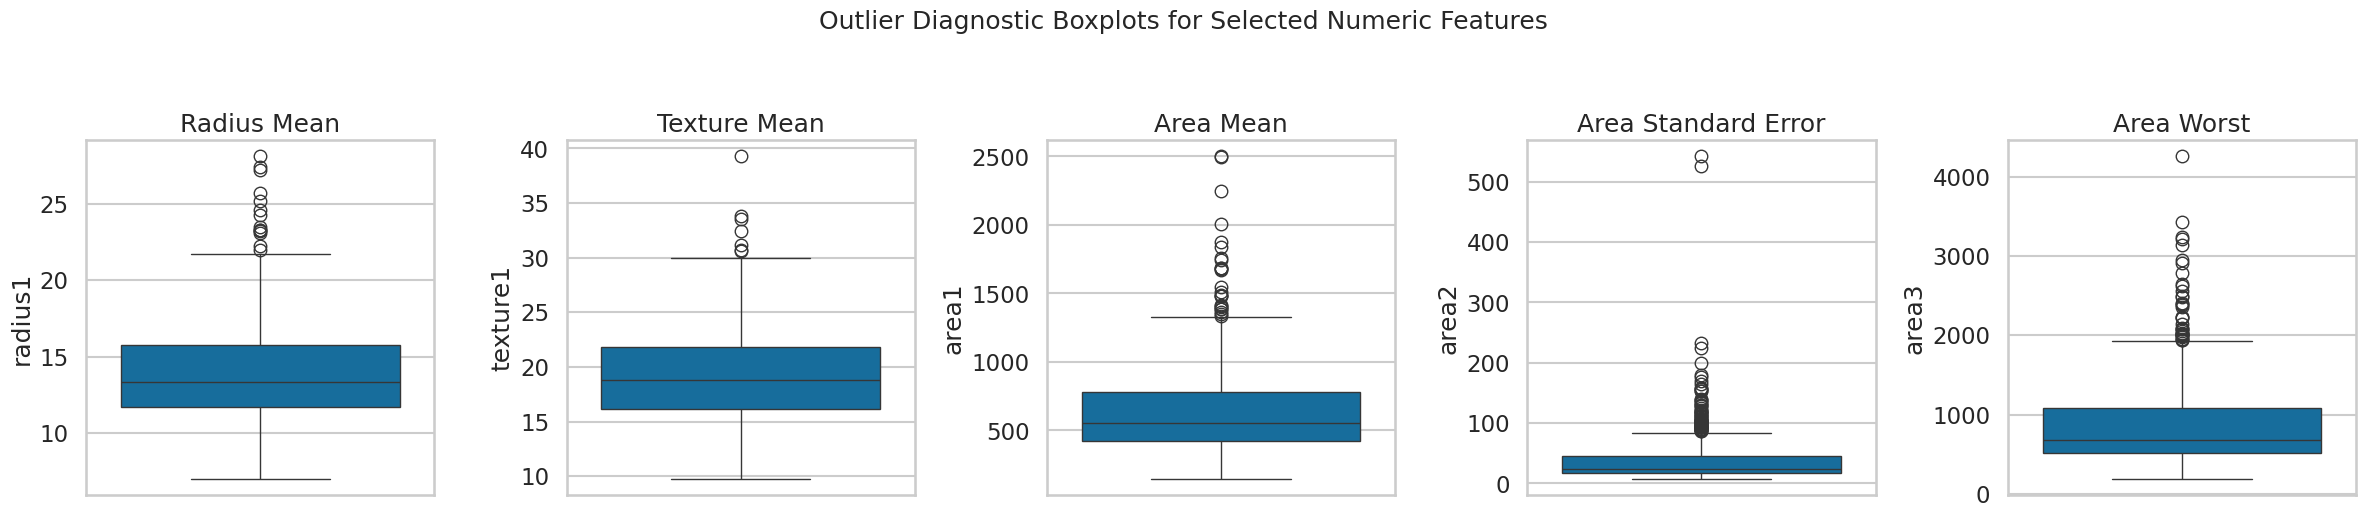

In [8]:

# Visual outlier inspection with boxplots for selected features
selected_outlier_features = [
    ("radius1", "Radius Mean"),
    ("texture1", "Texture Mean"),
    ("area1", "Area Mean"),
    ("area2", "Area Standard Error"),
    ("area3", "Area Worst")
]

fig, axes = plt.subplots(1, len(selected_outlier_features), figsize=(24, 5))
for ax, (feature_col, feature_title) in zip(axes, selected_outlier_features):
    sns.boxplot(y=df_clean[feature_col], ax=ax, color=palette[0])
    ax.set_title(feature_title)
    ax.set_xlabel("")
plt.suptitle("Outlier Diagnostic Boxplots for Selected Numeric Features", y=1.05, fontsize=18)
plt.tight_layout()
plt.show()



Both the IQR method and the Z-score method identify outliers in several biomedical measurements, especially area- and perimeter-related features. Because the dataset is relatively small and these extreme values may reflect genuine malignant cases rather than data entry errors, the observations are retained. Instead of deleting rows, the numeric predictors are capped (winsorized) using IQR-based limits, which reduces the influence of extreme values while preserving all patient records.


In [9]:

# Apply IQR-based capping to numeric predictor columns
df_capped = df_clean.copy()

for col in predictor_numeric_cols:
    lower, upper = bounds_dict[col]
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

# Check outlier reduction after capping
post_iqr_counts = []
for col in predictor_numeric_cols:
    count, _, _ = iqr_outlier_count(df_capped[col])
    post_iqr_counts.append((col, count))

post_iqr_df = pd.DataFrame(post_iqr_counts, columns=["feature", "post_cap_iqr_outlier_count"])

outlier_compare = outlier_summary.merge(post_iqr_df, on="feature")
outlier_compare["reduction"] = outlier_compare["iqr_outlier_count"] - outlier_compare["post_cap_iqr_outlier_count"]

print("Outlier counts before and after capping (top 15 by original IQR count):")
display(outlier_compare.sort_values("iqr_outlier_count", ascending=False).head(15))


Outlier counts before and after capping (top 15 by original IQR count):


,feature,iqr_outlier_count,zscore_outlier_count,iqr_outlier_percent,zscore_outlier_percent,post_cap_iqr_outlier_count,reduction
13,area2,65,6,11.4200,1.0500,0,65
10,radius2,38,7,6.6800,1.2300,0,38
12,perimeter2,38,8,6.6800,1.4100,0,38
23,area3,35,10,6.1500,1.7600,0,35
14,smoothness2,30,7,5.2700,1.2300,0,30
19,fractal_dimension2,28,10,4.9200,1.7600,0,28
15,compactness2,28,12,4.9200,2.1100,0,28
18,symmetry2,27,11,4.7500,1.9300,0,27
3,area1,25,8,4.3900,1.4100,0,25
29,fractal_dimension3,24,9,4.2200,1.5800,0,24


In [10]:

# Feature engineering
df_fe = df_capped.copy()

# Continuous engineered features
df_fe["area_perimeter_ratio"] = df_fe["area1"] / df_fe["perimeter1"].replace(0, np.nan)
df_fe["radius_worst_to_mean_ratio"] = df_fe["radius3"] / df_fe["radius1"].replace(0, np.nan)
df_fe["texture_range"] = df_fe["texture3"] - df_fe["texture1"]
df_fe["compactness_concavity_interaction"] = df_fe["compactness1"] * df_fe["concavity1"]

# Categorical engineered features for EDA and optional modeling
df_fe["radius_mean_band"] = pd.qcut(
    df_fe["radius1"], q=4, labels=["Q1_smallest", "Q2", "Q3", "Q4_largest"]
)
df_fe["texture_mean_band"] = pd.qcut(
    df_fe["texture1"], q=3, labels=["Low", "Medium", "High"]
)

print("Feature engineering complete.")
display(df_fe[[
    "radius1", "perimeter1", "area_perimeter_ratio",
    "radius3", "radius_worst_to_mean_ratio",
    "texture1", "texture3", "texture_range",
    "compactness1", "concavity1", "compactness_concavity_interaction",
    "radius_mean_band", "texture_mean_band"
]].head())


Feature engineering complete.


,radius1,perimeter1,area_perimeter_ratio,radius3,radius_worst_to_mean_ratio,texture1,texture3,texture_range,compactness1,concavity1,compactness_concavity_interaction,radius_mean_band,texture_mean_band
0,17.9900,122.8000,8.1515,25.3800,1.4108,10.3800,17.3300,6.9500,0.2286,0.2824,0.0646,Q4_largest,Low
1,20.5700,132.9000,9.9774,24.9900,1.2149,17.7700,23.4100,5.6400,0.0786,0.0869,0.0068,Q4_largest,Medium
2,19.6900,130.0000,9.2538,23.5700,1.1971,21.2500,25.5300,4.2800,0.1599,0.1974,0.0316,Q4_largest,High
3,11.4200,77.5800,4.9768,14.9100,1.3056,20.3800,26.5000,6.1200,0.2286,0.2414,0.0552,Q1_smallest,Medium
4,20.2900,135.1000,9.6003,22.5400,1.1109,14.3400,16.6700,2.3300,0.1328,0.1980,0.0263,Q4_largest,Low



### Feature Engineering Rationale

1. **`area_perimeter_ratio`** captures how much area is enclosed relative to the tumor perimeter and may help distinguish more compact from less compact masses.  
2. **`radius_worst_to_mean_ratio`** measures how extreme the worst radius is relative to the average radius, which may capture irregular growth behavior.  
3. **`texture_range`** summarizes the change from average texture to worst texture and may reveal variability not visible from a single measurement alone.  
4. **`compactness_concavity_interaction`** combines two shape-related features that are both clinically relevant and often associated with malignant structure.

These new variables were created to introduce additional information beyond the original measurements and potentially improve later model performance.


In [11]:

# Prepare final analysis-ready / modeling-ready dataset
df_model = df_fe.drop(columns=["Diagnosis"]).copy()

# One-hot encode the engineered categorical features
df_model = pd.get_dummies(
    df_model,
    columns=["radius_mean_band", "texture_mean_band"],
    drop_first=True,
    dtype=int
)

# Drop identifier from the modeling table
if "id" in df_model.columns:
    df_model = df_model.drop(columns=["id"])

# Robust scaling is appropriate because the dataset still contains skewness
# and we intentionally retained capped extremes rather than removing them.
scale_cols = [col for col in df_model.columns if col != "diagnosis_encoded"]

scaler = RobustScaler()
df_model_scaled = df_model.copy()
df_model_scaled[scale_cols] = scaler.fit_transform(df_model_scaled[scale_cols])

print("Final modeling dataset shape:")
print(df_model_scaled.shape)
display(df_model_scaled.head())


Final modeling dataset shape:
(569, 40)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,diagnosis_encoded,area_perimeter_ratio,radius_worst_to_mean_ratio,texture_range,compactness_concavity_interaction,radius_mean_band_Q2,radius_mean_band_Q3,radius_mean_band_Q4_largest,texture_mean_band_Medium,texture_mean_band_High
0,1.1324,-1.5027,1.2637,1.2414,1.1902,2.0768,2.1838,2.1159,1.8550,2.0392,2.1276,-0.3167,2.1111,2.2557,0.0064,1.4760,1.0326,0.6985,1.3582,1.3013,1.8010,-0.9352,2.1056,2.1990,1.0510,2.1628,1.8077,1.7152,2.0289,1.8846,1,0.9289,3.1827,0.2270,4.0738,0.0000,0.0000,1.0000,0.0000,0.0000
1,1.7647,-0.1901,1.6129,2.1382,-0.5880,-0.2137,0.2507,0.6830,0.0592,-0.5784,0.8897,-0.5844,0.6345,1.8124,-0.3880,-0.3805,-0.2704,0.3493,-0.5817,0.1494,1.7336,-0.2315,1.4807,2.1990,-0.2551,-0.1318,0.0555,0.8922,-0.1067,0.4355,1,1.8924,1.0200,-0.1071,0.0816,0.0000,0.0000,1.0000,1.0000,0.0000
2,1.5490,0.4281,1.5126,1.7988,0.7253,1.0273,1.3433,1.7582,0.8195,-0.1841,1.7095,-0.5016,1.3124,2.2557,-0.0773,1.0124,0.4611,1.3645,0.4531,0.5991,1.4879,0.0139,1.3282,1.7980,0.4456,1.1079,0.8335,1.4831,1.1719,0.3657,1,1.5106,0.8232,-0.4541,1.7917,0.0000,0.0000,1.0000,0.0000,1.0000
3,-0.4779,0.2735,-0.2993,-0.4553,1.9982,2.0768,1.7783,1.3354,1.9882,2.0439,0.6953,0.0750,0.6613,0.0988,0.9170,2.1195,1.1395,1.0945,2.0709,2.0935,-0.0104,0.1262,0.0293,-0.2089,2.0000,2.1628,1.7146,1.6334,2.0289,2.0839,1,-0.7463,2.0216,0.0153,3.4254,0.0000,0.0000,0.0000,1.0000,0.0000
4,1.6961,-0.7993,1.6889,2.0582,0.2340,0.6135,1.3492,1.3187,0.0503,-0.3219,1.7566,-0.5104,1.7995,2.2557,1.7165,0.2148,1.1495,1.1199,-0.1406,0.8346,1.3097,-1.0116,1.3209,1.5623,0.2075,-0.0360,0.6457,0.6486,-0.6785,-0.1581,1,1.6934,-0.1279,-0.9515,1.4273,0.0000,0.0000,1.0000,0.0000,0.0000



### Scaling Choice

RobustScaler was selected because it scales features using the median and interquartile range rather than the mean and standard deviation. This makes it a strong choice for a biomedical dataset like this one, where some variables remain skewed even after outlier capping. It is therefore more stable than MinMaxScaler or StandardScaler when extreme values are present.


In [12]:

# Before/after dataset summary comparison

def dataset_profile(df, stage_name):
    numeric_count = int(df.select_dtypes(include=[np.number]).shape[1])
    categorical_count = int(df.select_dtypes(exclude=[np.number]).shape[1])

    stats = {
        "Stage": stage_name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Numeric Columns": numeric_count,
        "Categorical Columns": categorical_count,
        "Total Missing Values": int(df.isna().sum().sum()),
        "Duplicate Rows": int(df.duplicated().sum())
    }

    for feature in ["radius_mean", "texture_mean", "area_mean"]:
        if feature in df.columns:
            stats[f"{feature} mean"] = round(float(df[feature].mean()), 4)
            stats[f"{feature} std"] = round(float(df[feature].std()), 4)

    return stats

comparison_table = pd.DataFrame([
    dataset_profile(df_before, "Raw dataset"),
    dataset_profile(df_fe, "Cleaned + engineered (EDA dataset)"),
    dataset_profile(df_model_scaled, "Final scaled modeling dataset")
])

print("Before/after summary comparison:")
display(comparison_table)


Before/after summary comparison:


,Stage,Rows,Columns,Numeric Columns,Categorical Columns,Total Missing Values,Duplicate Rows
0,Raw dataset,569,31,30,1,0,0
1,Cleaned + engineered (EDA dataset),569,38,35,3,0,0
2,Final scaled modeling dataset,569,40,40,0,0,0



## Part C. Exploratory Data Analysis and Visualization

The figures below are designed to tell a clear story about the distribution of tumor measurements, the relationship among variables, and how those patterns differ between benign and malignant diagnoses.

**Note:** The EDA uses the cleaned and capped dataset (`df_fe`) so that the plots remain readable while still preserving all observations.


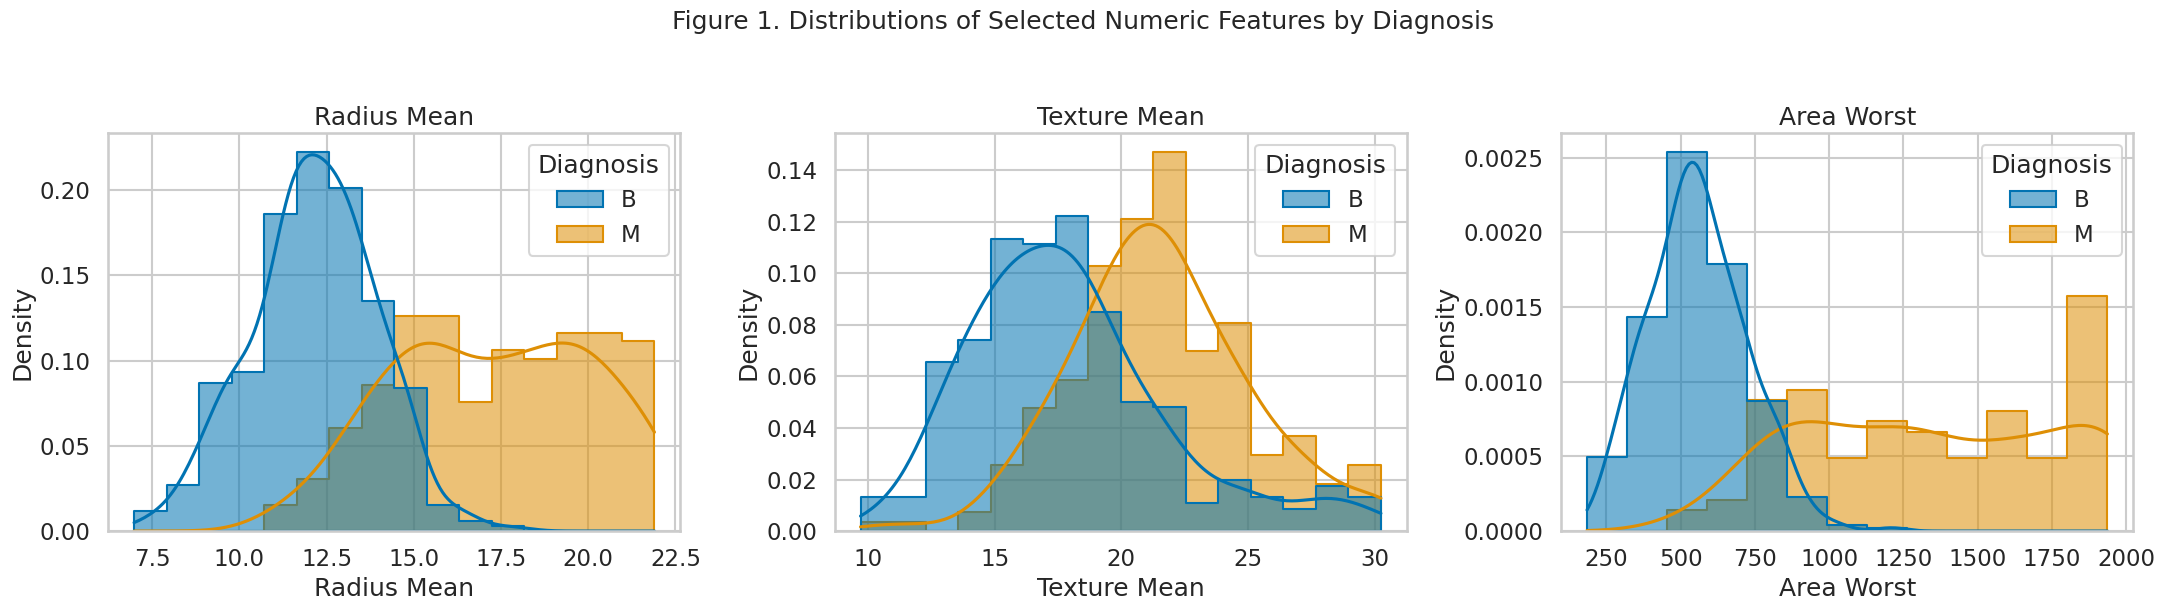

In [13]:

# Figure 1: Distribution plots for key numerical features
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

distribution_features = ["radius1", "texture1", "area3"]
for ax, feature in zip(axes, distribution_features):
    sns.histplot(
        data=df_fe, x=feature, hue="Diagnosis", kde=True,
        palette=diagnosis_palette, hue_order=diagnosis_order,
        ax=ax, alpha=0.55, element="step", stat="density", common_norm=False
    )
    # The title should still reflect the descriptive name for clarity
    if feature == "radius1":
        ax.set_title("Radius Mean")
        ax.set_xlabel("Radius Mean")
    elif feature == "texture1":
        ax.set_title("Texture Mean")
        ax.set_xlabel("Texture Mean")
    elif feature == "area3":
        ax.set_title("Area Worst")
        ax.set_xlabel("Area Worst")
    ax.set_ylabel("Density")

fig.suptitle("Figure 1. Distributions of Selected Numeric Features by Diagnosis", y=1.03, fontsize=18)
plt.tight_layout()
plt.show()



**Interpretation of Figure 1.**  
Figure 1 shows clear distributional separation between benign and malignant cases for several key measurements. Malignant tumors tend to have larger values for radius mean and area worst, which suggests that tumor size-related variables may be especially informative for classification. The texture distributions overlap more than the size variables, but they still show noticeable differences between the two diagnosis groups.


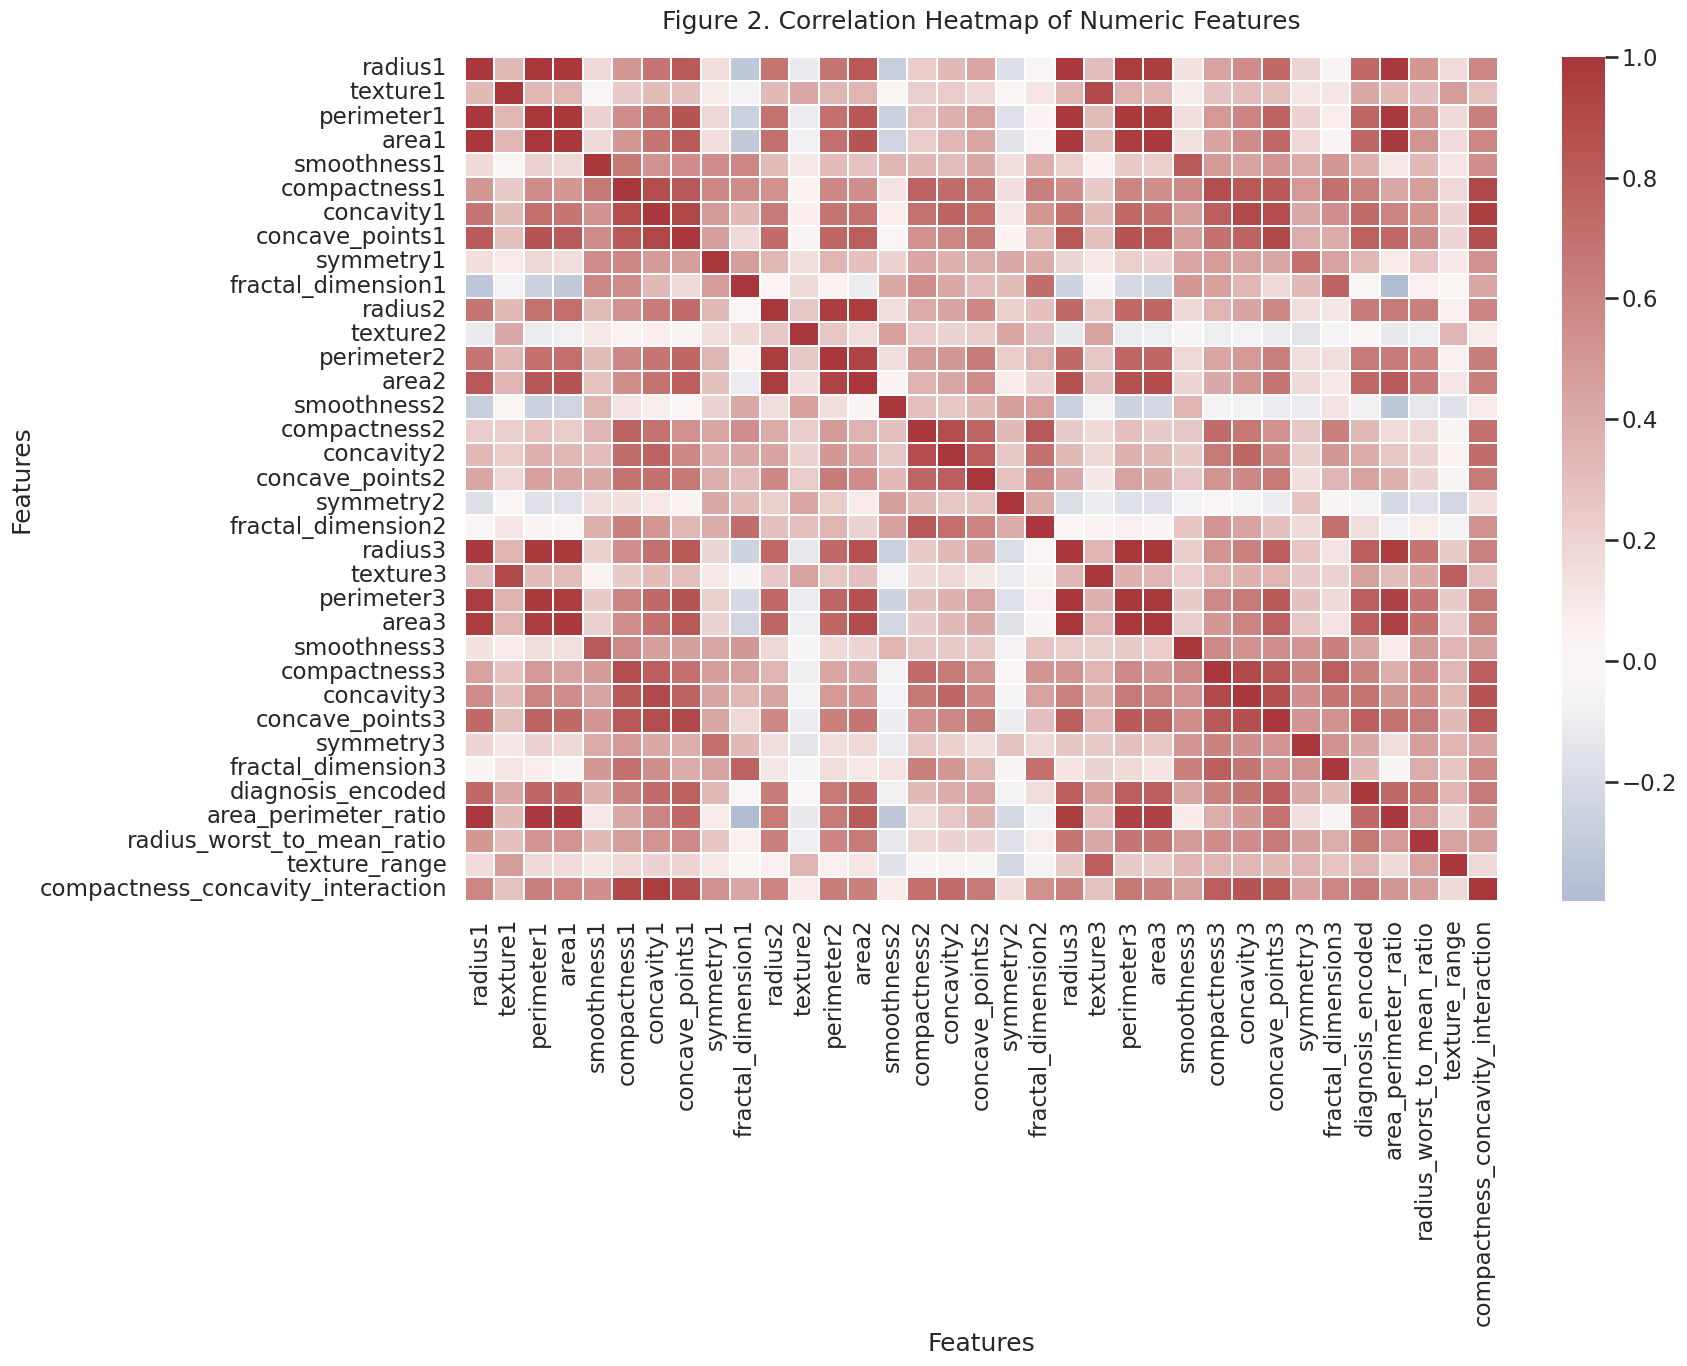

Strongest correlation pairs:


,Feature 1,Feature 2,Absolute Correlation
0,radius1,perimeter1,0.9977
1,radius1,area1,0.9939
2,radius3,perimeter3,0.9937
3,radius3,area3,0.9932
4,perimeter1,area1,0.9919
5,perimeter3,area3,0.9863
6,radius1,area_perimeter_ratio,0.9860
7,area1,area_perimeter_ratio,0.9820
8,perimeter1,area_perimeter_ratio,0.9766
9,perimeter1,radius3,0.9746


In [14]:

# Figure 2: Correlation heatmap
numeric_for_heatmap = df_fe.select_dtypes(include=[np.number])
#     numeric_for_heatmap = numeric_for_heatmap.drop(columns=["id"])
corr_matrix = numeric_for_heatmap.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, cmap="vlag", center=0, linewidths=0.2)
plt.title("Figure 2. Correlation Heatmap of Numeric Features", pad=20)
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Strongest correlations
corr_abs = corr_matrix.abs()
upper_triangle = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
top_corr_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
    .reset_index()
)
top_corr_pairs.columns = ["Feature 1", "Feature 2", "Absolute Correlation"]

print("Strongest correlation pairs:")
display(top_corr_pairs.head(10))



**Interpretation of Figure 2.**  
Figure 2 indicates that several size-related measurements are extremely highly correlated, especially radius mean, perimeter mean, and area mean. This is expected because these variables all describe related aspects of tumor size. The heatmap suggests that multicollinearity may be important to address in future modeling steps, especially for linear models that are sensitive to redundant predictors.


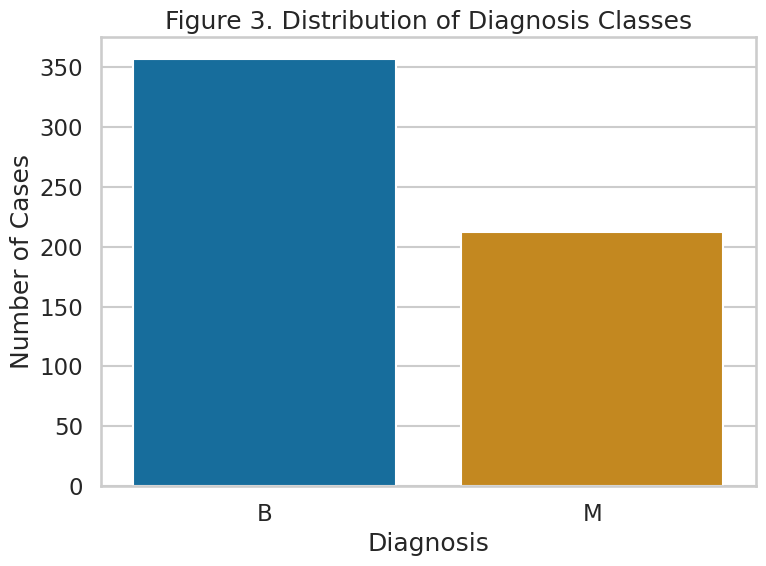

,Diagnosis,count,percent
0,B,357,62.7400
1,M,212,37.2600


In [15]:
# Figure 3: Diagnosis class distribution
plt.figure(figsize=(8, 6))
sns.countplot(
    data=df_fe, x="Diagnosis", order=diagnosis_order,
    hue="Diagnosis", hue_order=diagnosis_order,
    palette=diagnosis_palette, dodge=False, legend=False
)
plt.title("Figure 3. Distribution of Diagnosis Classes")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Cases")
plt.tight_layout()
plt.show()

diagnosis_counts = df_fe["Diagnosis"].value_counts().rename_axis("Diagnosis").reset_index(name="count")
diagnosis_counts["percent"] = (diagnosis_counts["count"] / diagnosis_counts["count"].sum() * 100).round(2)
display(diagnosis_counts)



**Interpretation of Figure 3.**  
Figure 3 shows that benign cases are more common than malignant cases in this dataset. The class distribution is not extremely imbalanced, but it is uneven enough that accuracy alone would not be the best evaluation metric in a later machine learning phase. This is a useful reminder that sensitivity, specificity, F1 score, and ROC-AUC would be important to report in future classification work.


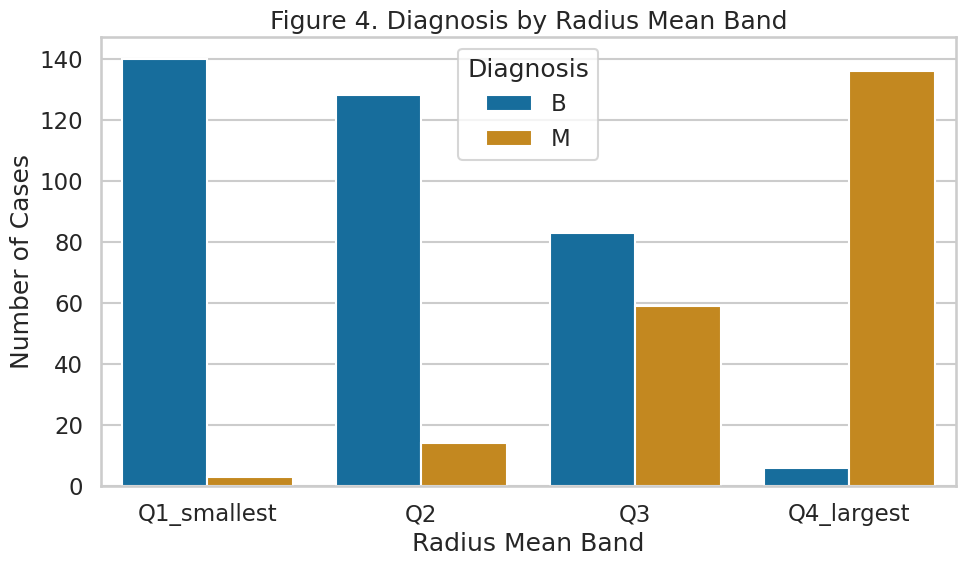

Diagnosis,B,M,All
radius_mean_band,,,
Q1_smallest,140,3,143
Q2,128,14,142
Q3,83,59,142
Q4_largest,6,136,142
All,357,212,569


In [16]:

# Figure 4: Categorical analysis of radius mean band by diagnosis
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_fe, x="radius_mean_band", hue="Diagnosis",
    palette=diagnosis_palette, hue_order=diagnosis_order
)
plt.title("Figure 4. Diagnosis by Radius Mean Band")
plt.xlabel("Radius Mean Band")
plt.ylabel("Number of Cases")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

display(pd.crosstab(df_fe["radius_mean_band"], df_fe["Diagnosis"], margins=True))



**Interpretation of Figure 4.**  
Figure 4 shows a strong shift in diagnosis composition across the radius-based quartile groups. The smaller radius bands contain many more benign cases, while the largest radius band contains a much higher concentration of malignant cases. This pattern reinforces the idea that tumor size is one of the clearest dimensions separating the two classes.


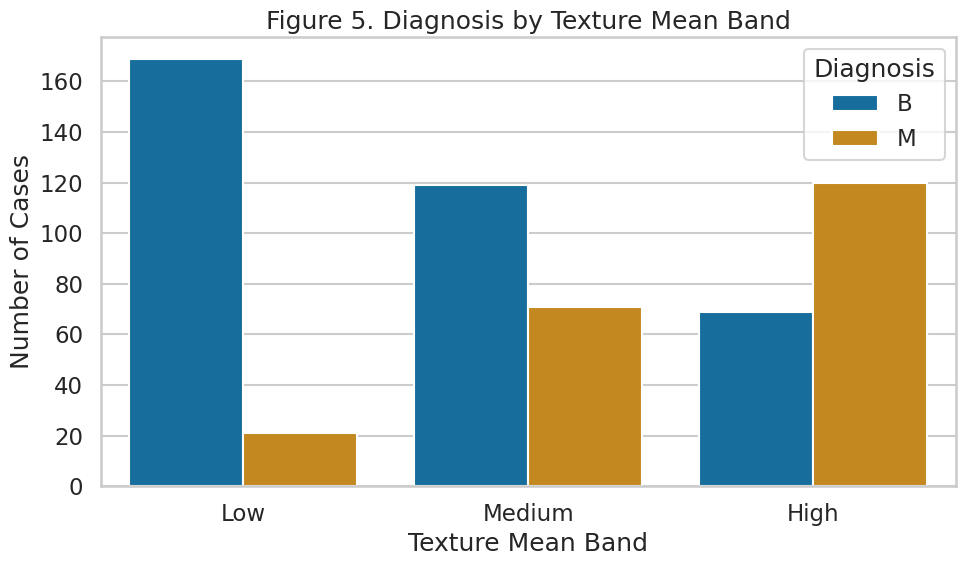

Diagnosis,B,M,All
texture_mean_band,,,
Low,169,21,190
Medium,119,71,190
High,69,120,189
All,357,212,569


In [17]:

# Figure 5: Categorical analysis of texture mean band by diagnosis
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_fe, x="texture_mean_band", hue="Diagnosis",
    palette=diagnosis_palette, hue_order=diagnosis_order
)
plt.title("Figure 5. Diagnosis by Texture Mean Band")
plt.xlabel("Texture Mean Band")
plt.ylabel("Number of Cases")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

display(pd.crosstab(df_fe["texture_mean_band"], df_fe["Diagnosis"], margins=True))



**Interpretation of Figure 5.**  
Figure 5 shows that texture also varies by diagnosis, although the separation is not as sharp as what we saw for the radius bands. Higher texture bands contain a larger share of malignant cases, which suggests that surface irregularity may still contribute useful information. However, texture appears to work best when interpreted together with other features rather than alone.


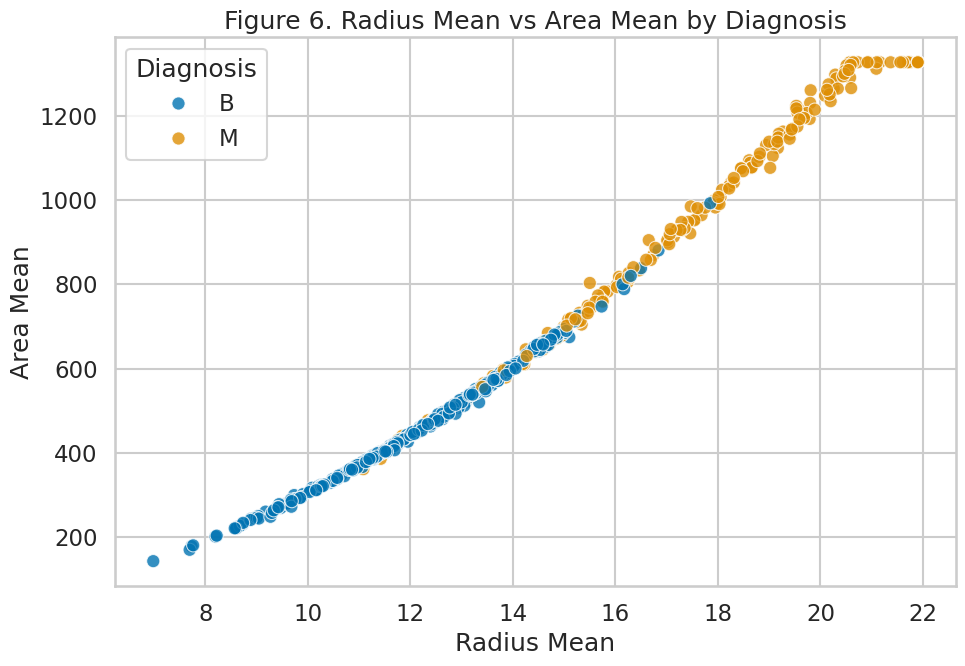

In [18]:

# Figure 6: Scatter plot exploring relationship between features and target
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_fe, x="radius1", y="area1",
    hue="Diagnosis", palette=diagnosis_palette, hue_order=diagnosis_order,
    s=90, alpha=0.8
)
plt.title("Figure 6. Radius Mean vs Area Mean by Diagnosis")
plt.xlabel("Radius Mean")
plt.ylabel("Area Mean")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()



**Interpretation of Figure 6.**  
Figure 6 highlights a strong positive relationship between radius mean and area mean, which is consistent with the correlation results. The malignant cases tend to occupy the upper-right portion of the plot, where both measurements are larger. The benign cases are more concentrated in the lower-left region, indicating that these two size-related features jointly provide strong class separation.


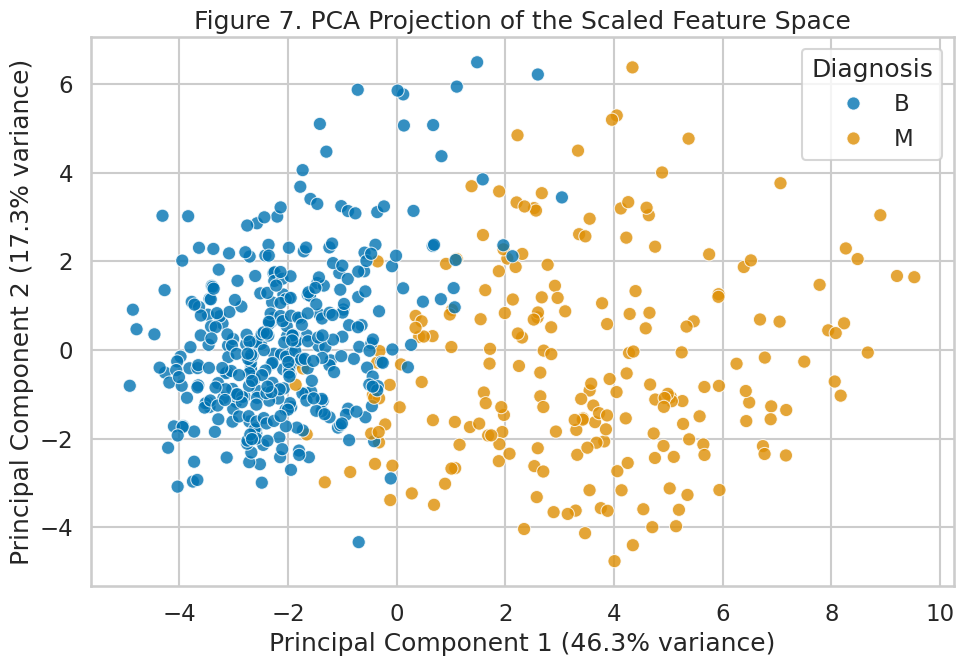

Explained variance by PC1 and PC2: 63.64%


In [19]:

# Figure 7: PCA on the final scaled modeling dataset (excluding target)
X_pca_input = df_model_scaled.drop(columns=["diagnosis_encoded"])
y_pca = df_fe["Diagnosis"].copy()

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_pca_input)

pca_df = pd.DataFrame(pca_components, columns=["PC1", "PC2"])
pca_df["diagnosis"] = y_pca.values

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="diagnosis", palette=diagnosis_palette, hue_order=diagnosis_order,
    s=90, alpha=0.8
)
plt.title("Figure 7. PCA Projection of the Scaled Feature Space")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

print(f"Explained variance by PC1 and PC2: {(pca.explained_variance_ratio_.sum()*100):.2f}%")



**Interpretation of Figure 7.**  
Figure 7 provides a lower-dimensional view of the high-dimensional feature space. Even after reducing the data to two principal components, the benign and malignant observations remain substantially separated, which suggests that the dataset contains strong underlying structure. This supports the expectation that machine learning models should be able to classify the target effectively after proper preprocessing.


## Export Cleaned and Scaled Data

In [21]:
output_filename = "breast_cancer_cleaned_scaled.csv"
df_model_scaled.to_csv(output_filename, index=False)
print(f"Cleaned and scaled dataset exported to {output_filename}")

Cleaned and scaled dataset exported to breast_cancer_cleaned_scaled.csv



## Conclusion

This notebook documented the full data pipeline from acquisition to cleaned, scaled, and visualized data. The dataset is well suited for supervised machine learning because the target variable is clearly defined, the predictors are clinically meaningful, and the exploratory analysis reveals strong structure in the feature space. After preprocessing, the final dataset is ready for ML.